Ô này dùng để thiết lập tài khoản Kaggle trong Colab. Nó tạo một thư mục .kaggle, sau đó lưu access_token vào một tệp trong thư mục đó và đặt quyền truy cập để chỉ mình t mới có thể đọc được tệp đó. Điều này cho phép tải xuống các bộ dữ liệu từ Kaggle trực tiếp trong Colab.

In [ ]:
!mkdir -p ~/.kaggle
!echo KGAT_aade15e49b0b38b5b0297eaa2b4690b3 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# **DATASET 1: E-COMMERCE**

In [ ]:
import pandas as pd
# thư viện này dùng để tìm các tệp và thư mục theo 1 mẫu đc chỉ định (vd tất cả các tệp có đuôi .jpg)
import glob
# module này cung cấp cách để tương tác với hdh như truy cập vào thư mục, đường dẫn tệp
import os

print("\nKẾT QUẢ EDA DATASET 1: E-COMMERCE")

# Quét sâu tìm file CSV ở mọi thư mục con
csv_files_potential = glob.glob('**/*.csv', recursive=True)

if csv_files_potential:
    csv_file_path = csv_files_potential[0]
    # Xác định thư mục gốc của dataset dựa trên vị trí của file CSV đầu tiên tìm thấy
    dataset_root = os.path.dirname(csv_file_path) or '.' # Nếu CSV ở thư mục hiện tại, dùng '.'
    print(f"\nFile data: {csv_file_path}")
    print(f"Thư mục gốc của Dataset 1: {dataset_root}")

    # Quét tìm và đếm tổng số lượng ảnh (jpg, png) CHỈ TRONG dataset_root này
    image_files = glob.glob(os.path.join(dataset_root, '**/*.jpg'), recursive=True) + \
                  glob.glob(os.path.join(dataset_root, '**/*.png'), recursive=True) + \
                  glob.glob(os.path.join(dataset_root, '**/*.jpeg'), recursive=True)
    print(f"Tổng số lượng ảnh tìm thấy: {len(image_files)} ảnh")

    # dòng này đọc tệp csv đầu tiên đã tìm thấy 1 dataframe của pandas và skip các dòng lỗi
    df1 = pd.read_csv(csv_file_path, on_bad_lines='skip')
    print(f"Tổng số mẫu/dòng: {df1.shape[0]}")
    print(f"Các trường dữ liệu/cột: {df1.shape[1]}")
    print("\nChi tiết các trường:")
    # in ra tóm tát các thông tin về dataframe df1 bao gồm kiểu dữ liệu của từng cột,
    # số lượng giá trị k rỗng, mức sử dụng bộ nhớ
    print(df1.info())
    print("\nVấn đề chất lượng / số lượng dữ liệu trống ở mỗi cột:")

    # dòng này tính tổng số lượng giá trị rỗng cho mỗi cột, df1.null() trẩ về 1 dataframe boolean cho biết
    # vị trí các giá trị rỗng và sum() tính tổng True cho mỗi cột
    print(f"Tổng giá trị thiếu: {df1.isnull().sum()}")
    print(f"Tổng giá trị thiếu trên toàn bộ DataFrame df1: {df1.isnull().sum().sum()}")
    print("\nDữ liệu mẫu (2 dòng đầu):")
    display(df1.head(2))
else:
    print("\nXác nhận: Bộ dữ liệu này CHỈ CHỨA ẢNH, không có file CSV metadata đi kèm.")
    # Quét tìm và đếm tổng số lượng ảnh (jpg, png) trong thư mục hiện tại và thư mục con (recursive=True)
    image_files = glob.glob('**/*.jpg', recursive=True) + glob.glob('**/*.png', recursive=True) + glob.glob('**/*.jpeg', recursive=True)
    print(f"Tổng số lượng ảnh tìm thấy: {len(image_files)} ảnh")
    # Show thử tên của 5 file ảnh đầu tiên làm mẫu
    print("\nVài file ảnh mẫu:")
    for img in image_files[:5]:
        print(img)


KẾT QUẢ EDA DATASET 1: E-COMMERCE

File data: sample_data/california_housing_test.csv
Thư mục gốc của Dataset 1: sample_data
Tổng số lượng ảnh tìm thấy: 0 ảnh
Tổng số mẫu/dòng: 3000
Các trường dữ liệu/cột: 9

Chi tiết các trường:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB
None

Vấn đề chất lượng / số lượng dữ liệu trống ở mỗi cột:
Tổng giá trị thiếu: lo

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0


Đây là bản nhẹ hơn so với bản 15gb, Ô này thực hiện tìm styles.csv và đọc nó vào 1 dataframe. Sau đó in ra tổng số dòng, cột, số lượng giá trị trong mỗi cột của dataframe. Chọn 3 ảnh mẫu từ thư mục images và hiển thị chúng.

# **DATASET 2: FASHION PRODUCT IMAGES DATASET**

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-dataset
License(s): MIT
100% 23.1G/23.1G [03:13<00:00, 128MB/s]


KẾT QUẢ EDA DATASET 2: FASHION
Đã tìm thấy dữ liệu gốc tại: /content
Tổng số mẫu (ảnh/dòng): 44424
Tổng số trường dữ liệu (cột): 10

Vấn đề chất lượng (Số lượng dữ liệu rỗng ở mỗi cột):
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64
Tổng giá trị thiếu trên toàn bộ DataFrame df2: 361

Ảnh mẫu:


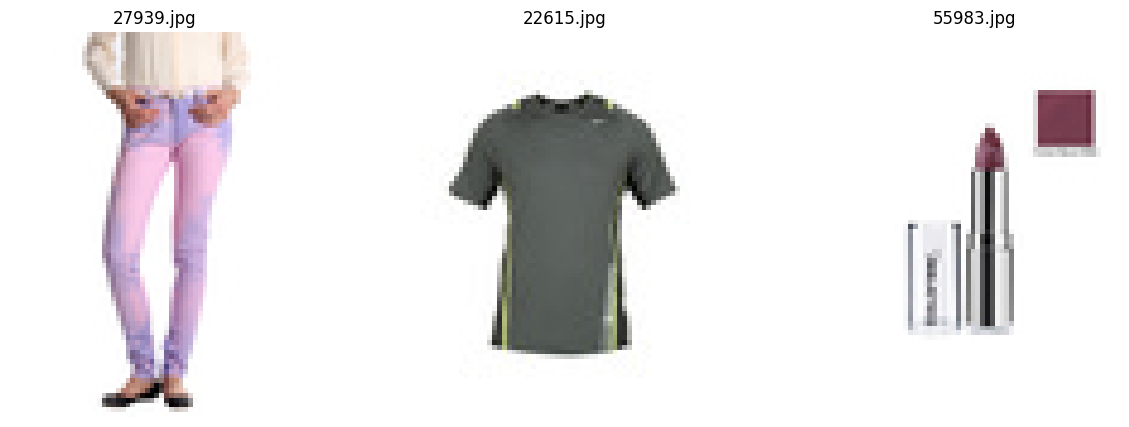

In [ ]:
!kaggle datasets download -d paramaggarwal/fashion-product-images-dataset --unzip

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("\nKẾT QUẢ EDA DATASET 2: FASHION")

# Thay vì fix cứng đường dẫn, ta cho máy quét tìm file styles.csv trong toàn bộ thư mục /content/
# Điều này đảm bảo tóm được file dù Kaggle có giải nén lồng thư mục hay không
fashion_csv_paths = glob.glob('/content/**/styles.csv', recursive=True)

if fashion_csv_paths:
    fashion_csv_path = fashion_csv_paths[0]
    # Lấy thư mục chứa file styles.csv làm thư mục gốc (dataset_root)
    dataset_root = os.path.dirname(fashion_csv_path)
    print(f"Đã tìm thấy dữ liệu gốc tại: {dataset_root}")

    # Đọc dữ liệu
    df2 = pd.read_csv(fashion_csv_path, on_bad_lines='skip')

    print(f"Tổng số mẫu (ảnh/dòng): {df2.shape[0]}")
    print(f"Tổng số trường dữ liệu (cột): {df2.shape[1]}")
    print("\nVấn đề chất lượng (Số lượng dữ liệu rỗng ở mỗi cột):")
    print(df2.isnull().sum())
    print(f"Tổng giá trị thiếu trên toàn bộ DataFrame df2: {df2.isnull().sum().sum()}")

    # Tìm thư mục ảnh dựa trên dataset_root vừa xác định
    img_folder = os.path.join(dataset_root, 'images')

    if os.path.exists(img_folder):
        # Liệt kê tất cả các tệp và lấy ra 3 tệp đầu tiên
        sample_imgs = os.listdir(img_folder)[:3]

        print("\nẢnh mẫu:")
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        for i, img_name in enumerate(sample_imgs):
            img_path = os.path.join(img_folder, img_name)
            img = mpimg.imread(img_path)
            ax[i].imshow(img)
            ax[i].axis('off')
            ax[i].set_title(img_name)
        plt.show()
    else:
        print(f"\nKhông tìm thấy thư mục 'images' bên trong {dataset_root}.")
else:
    print("\nKhông tìm thấy file 'styles.csv'. Vui lòng đợi quá trình giải nén hoàn tất hoặc kiểm tra lại ổ đĩa Colab.")

Ô này tải dữ liệu từ kaggle sau đó đếm tổng số lượng ảnh jpg và png, tìm các tệp metadata (json hoặc csv) đọc tệp đầu tiên và in ra thông tin về số dòng, số cột và dữ liệu rỗng. Cuối cùng hiển thị 3 mẫu ảnh ngẫu nhiên.

# **DATASET 3: FASHION IQ**

Dataset URL: https://www.kaggle.com/datasets/hoangkim14/fashion-iq-dataset
License(s): other
100% 630M/630M [00:05<00:00, 127MB/s]


KẾT QUẢ EDA DATASET 3: FASHION IQ
Tổng số lượng ảnh tìm thấy: 74381 ảnh

Đã tìm thấy file metadata tại: /content/fashionIQ_dataset/captions/cap.dress.test.json
Tổng số mẫu (dòng): 2024
Các trường dữ liệu (cột): 2

Vấn đề chất lượng (dữ liệu rỗng):
candidate    0
captions     0
dtype: int64
Tổng giá trị thiếu trên toàn bộ DataFrame df3: 0


,candidate,captions
0,B007E66YTO,"[ yello and more flowing, short and black]"
1,B007CPAGDW,[sleeveless satin dress gold and black with or...



Ảnh mẫu:


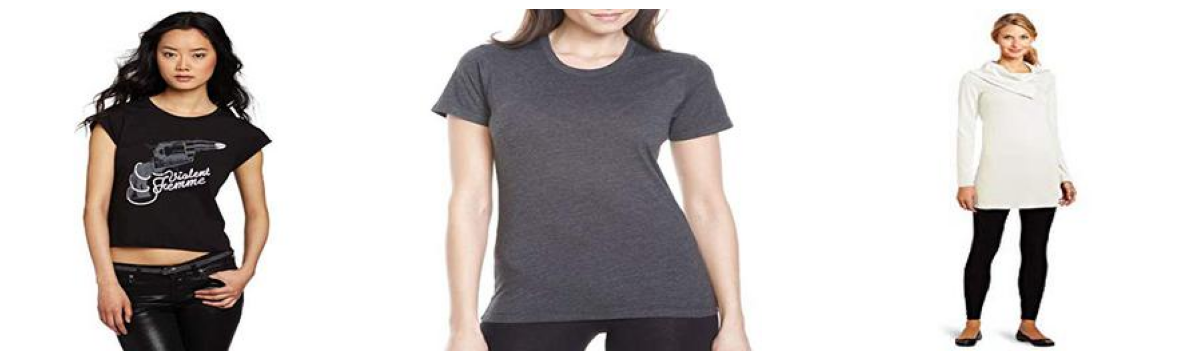

In [ ]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Tải và giải nén Dataset 3
!kaggle datasets download -d hoangkim14/fashion-iq-dataset --unzip

print("\nKẾT QUẢ EDA DATASET 3: FASHION IQ")

# Từ output trước, dataset này giải nén vào thư mục 'fashionIQ_dataset'
dataset_root = '/content/fashionIQ_dataset/' # Thư mục gốc cụ thể cho dataset này

# Quét đếm ảnh CHỈ TRONG dataset_root này
image_files = glob.glob(os.path.join(dataset_root, '**/*.jpg'), recursive=True) + \
              glob.glob(os.path.join(dataset_root, '**/*.png'), recursive=True)
print(f"Tổng số lượng ảnh tìm thấy: {len(image_files)} ảnh")

# Quét tìm file JSON hoặc CSV (vì Fashion IQ thường lưu metadata dạng JSON) CHỈ TRONG dataset_root này
meta_files = glob.glob(os.path.join(dataset_root, '**/*.json'), recursive=True) + \
             glob.glob(os.path.join(dataset_root, '**/*.csv'), recursive=True)

if meta_files:
    print(f"\nĐã tìm thấy file metadata tại: {meta_files[0]}")
    # Đọc thử file đầu tiên JSON/CSV
    try:
        if meta_files[0].endswith('.csv'):
            df3 = pd.read_csv(meta_files[0])
        else:
            df3 = pd.read_json(meta_files[0])

        print(f"Tổng số mẫu (dòng): {df3.shape[0]}")
        print(f"Các trường dữ liệu (cột): {df3.shape[1]}")
        print("\nVấn đề chất lượng (dữ liệu rỗng):")
        print(df3.isnull().sum())
        print(f"Tổng giá trị thiếu trên toàn bộ DataFrame df3: {df3.isnull().sum().sum()}")
        display(df3.head(2))
    except Exception as e:
        print(f"Không thể đọc metadata tự động: {e}")
else:
    print(f"\nChỉ tìm thấy ảnh, không thấy file metadata trong {dataset_root}.")

# Hiển thị 3 ảnh mẫu
if image_files:
    print("\nẢnh mẫu:")
    fig, ax = plt.subplots(1, min(3, len(image_files)), figsize=(15, 5))
    for i in range(min(3, len(image_files))):
        img = mpimg.imread(image_files[i])
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

Tương tự đếm số lượng ảnh jpg, tìm các tệp metadata dạng json, đọc và in ra thông tin tương tự

# **DATASET 4: DEEPFASHION**

Dataset URL: https://www.kaggle.com/datasets/silverstone1903/deep-fashion-multimodal
License(s): CC-BY-NC-SA-4.0
100% 1.89G/1.89G [00:33<00:00, 60.7MB/s]


KẾT QUẢ EDA DATASET 4: DEEPFASHION
Tổng số lượng ảnh tìm thấy: 12278 ảnh

Danh sách các file metadata thực tế có trong bộ dữ liệu này:
 - /content/dataset4/labels_front.csv

Đang tiến hành đọc file: /content/dataset4/labels_front.csv
Tổng số mẫu (dòng): 12278
Các trường dữ liệu (cột): 7

Vấn đề chất lượng (Số lượng ô rỗng):
image_id        0
caption         0
path            0
gender          0
product_type    0
product_id      0
image_type      0
dtype: int64
Tổng giá trị thiếu trên toàn bộ DataFrame df4: 0


,image_id,caption,path,gender,product_type,product_id,image_type
0,MEN-Denim-id_00000089-28_1_front,This gentleman is wearing a medium-sleeve shir...,MEN-Denim-id_00000089-28_1_front.jpg,MEN,Denim,id_00000089,front
1,MEN-Denim-id_00000265-01_1_front,This person is wearing a short-sleeve shirt wi...,MEN-Denim-id_00000265-01_1_front.jpg,MEN,Denim,id_00000265,front
2,MEN-Denim-id_00000313-01_1_front,The gentleman is wearing a short-sleeve T-shir...,MEN-Denim-id_00000313-01_1_front.jpg,MEN,Denim,id_00000313,front



Ảnh mẫu DeepFashion-MultiModal:


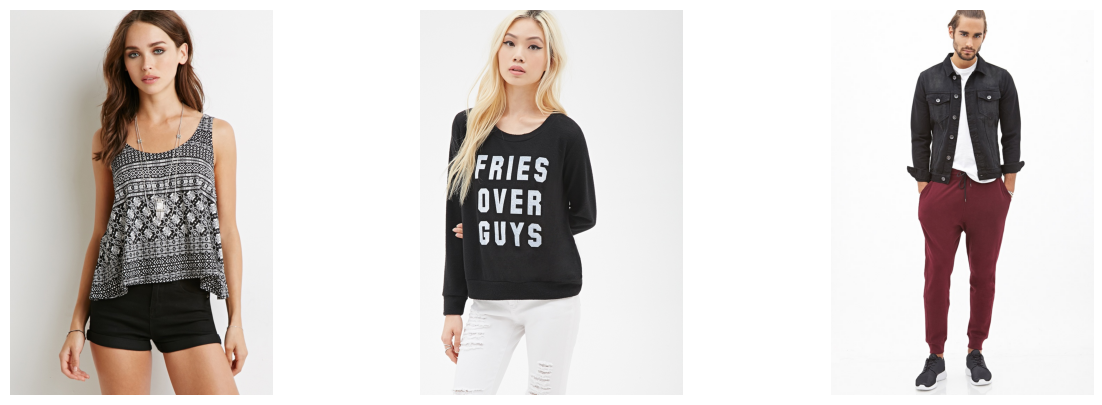

In [22]:
# Tạo thư mục riêng và giải nén Dataset 4 khép kín vào đó
!mkdir -p /content/dataset4
!kaggle datasets download -d silverstone1903/deep-fashion-multimodal -p /content/dataset4 --unzip

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("\nKẾT QUẢ EDA DATASET 4: DEEPFASHION")

# Quét ảnh bên trong dataset4
image_files = glob.glob('/content/dataset4/**/*.jpg', recursive=True) + glob.glob('/content/dataset4/**/*.png', recursive=True)
print(f"Tổng số lượng ảnh tìm thấy: {len(image_files)} ảnh")

# Quét metadata bên trong dataset4
all_meta_files = glob.glob('/content/dataset4/**/*.csv', recursive=True) + \
                 glob.glob('/content/dataset4/**/*.json', recursive=True) + \
                 glob.glob('/content/dataset4/**/*.txt', recursive=True)

print("\nDanh sách các file metadata thực tế có trong bộ dữ liệu này:")
for f in all_meta_files:
    print(f" - {f}")

# Đọc thử file metadata đầu tiên tìm được
if all_meta_files:
    target_file = all_meta_files[0]
    print(f"\nĐang tiến hành đọc file: {target_file}")
    try:
        if target_file.endswith('.csv') or target_file.endswith('.txt'):
            df4 = pd.read_csv(target_file, sep=None, engine='python', on_bad_lines='skip')
        else:
            df4 = pd.read_json(target_file)

        print(f"Tổng số mẫu (dòng): {df4.shape[0]}")
        print(f"Các trường dữ liệu (cột): {df4.shape[1]}")
        print("\nVấn đề chất lượng (Số lượng ô rỗng):")
        print(df4.isnull().sum())
        print(f"Tổng giá trị thiếu trên toàn bộ DataFrame df4: {df4.isnull().sum().sum()}")
        display(df4.head(3))
    except Exception as e:
        print(f"Lỗi khi cố gắng đọc file {target_file}: {e}")
else:
    print("\nKhông tìm thấy file metadata.")

# Hiển thị 3 ảnh mẫu của Dataset 4
if image_files:
    print("\nẢnh mẫu DeepFashion-MultiModal:")
    n_show = min(3, len(image_files))
    fig, ax = plt.subplots(1, n_show, figsize=(15, 5))
    if n_show == 1:
        ax = [ax]
    for i in range(n_show):
        img = mpimg.imread(image_files[i])
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

Ô này tải 1 bản mirror của bộ dữ liệu do không tải được trực tiếp tử kaggle. Bao gồm đếm tổng số lượng ảnh jpg và png, tìm tệp articles.csv chứa thông tin sản phẩm của H&M và đọc nó vào dataframe sau đó in các thông tin cơ bản như số dòng, cột, chi tiết cột, dữ liệu rỗng và hiển thị 2 dòng dầu tiên. Cuối cùng hiển thị 3 mẫu từ bộ dữ liệu.

# **DATASET 5: H&M BẢN MIRROR**

In [20]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Tải bộ H&M từ Public Dataset thay vì Competition
!kaggle datasets download -d derrickmwiti/hm-personalized-fashion-recommendations --unzip

print("\nKẾT QUẢ EDA DATASET 5: H&M BẢN MIRROR")

# Tìm kiếm file articles.parquet trên toàn bộ thư mục /content/ để xác định dataset_root
hm_parquet_candidates = glob.glob('/content/**/articles.parquet', recursive=True)

df_hm = None
if hm_parquet_candidates:
    hm_parquet_path = hm_parquet_candidates[0]
    dataset_root = os.path.dirname(hm_parquet_path) # Xác định thư mục chứa articles.parquet

    print(f'\nĐã tìm thấy file metadata tại: {hm_parquet_path}')
    print(f'Thư mục gốc của Dataset 5: {dataset_root}')

    df_hm = pd.read_parquet(hm_parquet_path)

    print(f'\nTổng số mẫu (dòng): {df_hm.shape[0]}')
    print(f'Các trường dữ liệu (cột): {df_hm.shape[1]}')
    print('\nChi tiết các trường:')
    print(df_hm.info())
    print('\nVấn đề chất lượng (Dữ liệu rỗng):')
    print(df_hm.isnull().sum())
    print(f'Tổng giá trị thiếu trên toàn bộ DataFrame df_hm: {df_hm.isnull().sum().sum()}')
    display(df_hm.head(2))

    print('\nLƯU Ý: Bộ dữ liệu H&M này (derrickmwiti/hm-personalized-fashion-recommendations) chủ yếu cung cấp dữ liệu dạng bảng và không bao gồm hình ảnh sản phẩm trực tiếp. Các hình ảnh hiển thị trước đây có thể đến từ các bộ dữ liệu khác đã được giải nén trong cùng thư mục.')

    # Loại bỏ phần hiển thị ảnh vì bộ dữ liệu này không có ảnh đi kèm
    # Để hiển thị ảnh H&M, cần tải một bộ dữ liệu H&M khác có chứa hình ảnh sản phẩm.
else:
    print(f"\nKhông tìm thấy file articles.parquet trong bất kỳ thư mục nào trong '/content/'. Vui lòng kiểm tra tên file hoặc dataset đã được giải nén thành công chưa.")

Dataset URL: https://www.kaggle.com/datasets/derrickmwiti/hm-personalized-fashion-recommendations
License(s): unknown
100% 709M/709M [00:07<00:00, 99.2MB/s]


KẾT QUẢ EDA DATASET 5: H&M BẢN MIRROR

Đã tìm thấy file metadata tại: /content/articles.parquet
Thư mục gốc của Dataset 5: /content

Tổng số mẫu (dòng): 105542
Các trường dữ liệu (cột): 25

Chi tiết các trường:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-n

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.



LƯU Ý: Bộ dữ liệu H&M này (derrickmwiti/hm-personalized-fashion-recommendations) chủ yếu cung cấp dữ liệu dạng bảng và không bao gồm hình ảnh sản phẩm trực tiếp. Các hình ảnh hiển thị trước đây có thể đến từ các bộ dữ liệu khác đã được giải nén trong cùng thư mục.
